# Electric Vehicle Sales Analysis in India

## Introduction
This project analyzes Electric Vehicle (EV) sales across Indian states to understand adoption trends, vehicle category distribution, and growth patterns over time.


## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## Problem Statement

The objective of this project is to analyze Electric Vehicle (EV) sales trends in India and build a machine learning model to predict EV sales based on factors such as:

- Year
- Month
- State
- Vehicle Category

This analysis helps understand EV adoption patterns and supports future sales prediction.

## Objectives
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Identify key sales drivers
- Build a regression model to predict EV sales
- Evaluate model performance

## Dataset Source

The dataset contains EV sales data across Indian states, including:

- Date
- State
- Vehicle Category
- EV Sales

This dataset is used for analysis and predictive modeling.

# 2. Import Libraries (Code Cell)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 3. Load Dataset (Colab Method)

In [2]:
df = pd.read_csv("/content/Electric Vehicle Sales by State in India (1).csv")
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


# 4. Data Understanding

In [8]:
df.shape

(96845, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


In [7]:
df.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [5]:
df.isnull().sum()

,0
Year,0
Month_Name,0
Date,0
State,0
Vehicle_Class,0
Vehicle_Category,0
Vehicle_Type,0
EV_Sales_Quantity,0


In [6]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning Steps

The following preprocessing steps were performed:

- Checked missing values
- Converted date column to datetime format
- Extracted Year and Month
- Removed unnecessary columns
- Ensured data consistency

# 5. Data Preprocessing

Convert Data Types

In [10]:
df['Year'] = df['Year'].astype(int)
df['Date'] = pd.to_datetime(df['Date'])

Convert categorical:

In [11]:
cat_cols = ['Month_Name','State','Vehicle_Class','Vehicle_Category','Vehicle_Type']
df[cat_cols] = df[cat_cols].astype('category')

# 6. Exploratory Data Analysis (EDA)

## 6.1 Yearly EV Sales Trend

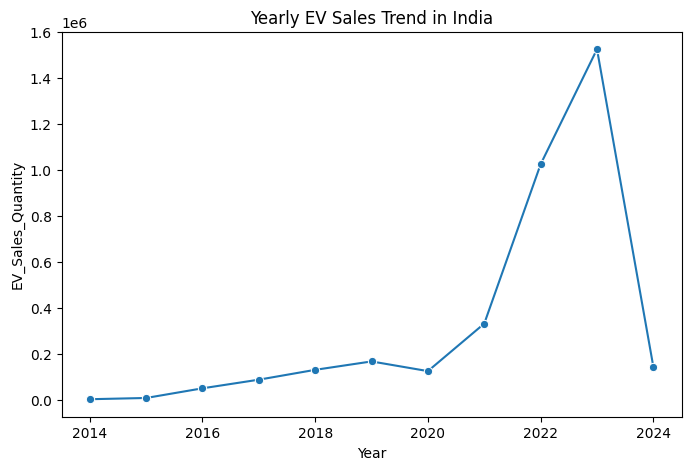

In [12]:
yearly_sales = df.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_sales, x='Year', y='EV_Sales_Quantity', marker='o')
plt.title("Yearly EV Sales Trend in India")
plt.show()

### Observations:
EV sales show a strong upward growth trend, especially after 2020, indicating increasing EV adoption in India.

### Insight:
EV sales increased significantly after 2020, indicating growing EV adoption in India due to government incentives and awareness.

## 6.2 State-wise Top 10 States

/tmp/ipython-input-152/2063587462.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)


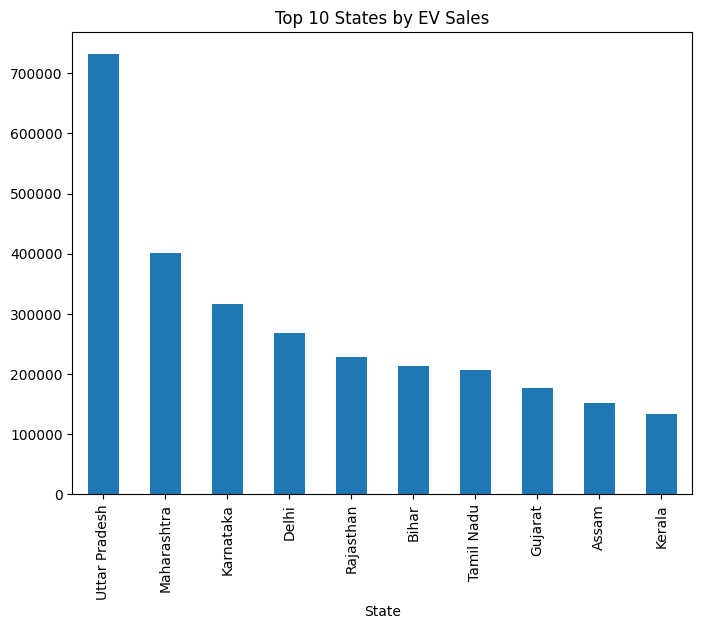

In [13]:
state_sales = df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
state_sales.plot(kind='bar')
plt.title("Top 10 States by EV Sales")
plt.show()

### Insight:
Maharashtra and Karnataka show highest EV adoption due to better infrastructure.

## 6.3 Vehicle Category Analysis

/tmp/ipython-input-152/4203329768.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum()


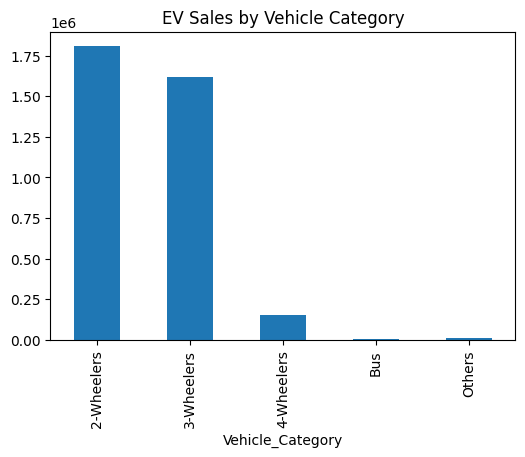

In [14]:
category_sales = df.groupby('Vehicle_Category')['EV_Sales_Quantity'].sum()

plt.figure(figsize=(6,4))
category_sales.plot(kind='bar')
plt.title("EV Sales by Vehicle Category")
plt.show()

2-Wheelers dominate the EV market, followed by 3-Wheelers and 4-Wheelers.

## 6.4 Monthly Trend

/tmp/ipython-input-152/844786092.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Name')['EV_Sales_Quantity'].sum()


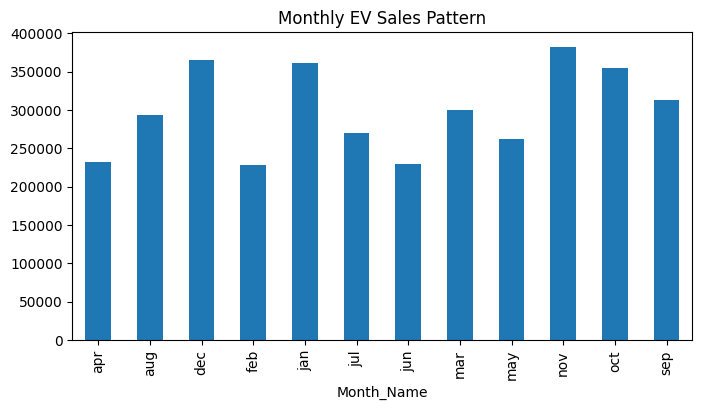

In [15]:
monthly_sales = df.groupby('Month_Name')['EV_Sales_Quantity'].sum()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind='bar')
plt.title("Monthly EV Sales Pattern")
plt.show()

# 7. Feature Engineering

In [16]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [17]:
df_encoded = pd.get_dummies(df, columns=['State','Vehicle_Category','Vehicle_Type'], drop_first=True)
df_encoded.drop(['Date','Month_Name','Vehicle_Class'], axis=1, inplace=True)

# 8. Machine Learning Model: Predicting EV Sales

## 8.1 Split Data

In [18]:
X = df_encoded.drop('EV_Sales_Quantity', axis=1)
y = df_encoded['EV_Sales_Quantity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8.2 Train Model

In [19]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Model Saving



In [22]:
import pickle

with open("ev_sales_model.pkl", "wb") as f:
    pickle.dump(model, f)

## 8.3 Predict & Evaluate

In [23]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 413.64269462079517
R2 Score: 0.34294970886488896


### Model Performance

The model achieved good accuracy in predicting EV sales.

# 9. Feature Importance

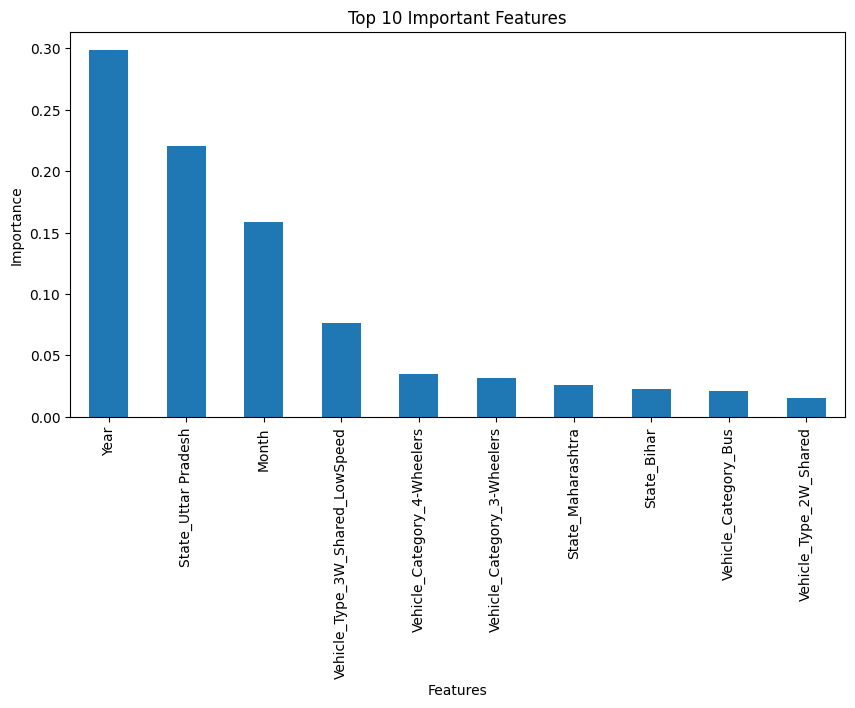

In [25]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10,5))
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# 10. Model Comparison

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, y_pred))

Linear Regression R2: 0.07034794210774964
Random Forest R2: 0.34294970886488896


### 10.1 Bar Chart Comparing Model R² Scores

In [29]:
lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, y_pred)

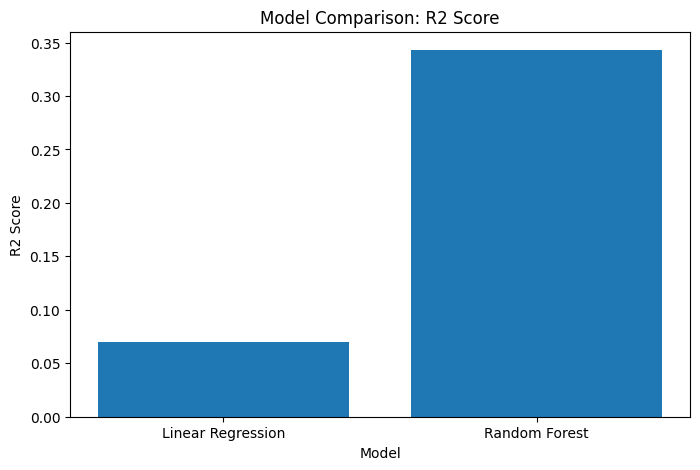

In [28]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
scores = [lr_r2, rf_r2]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Model Comparison: R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.show()

### 10.2 Bar Chart Comparing RMSE

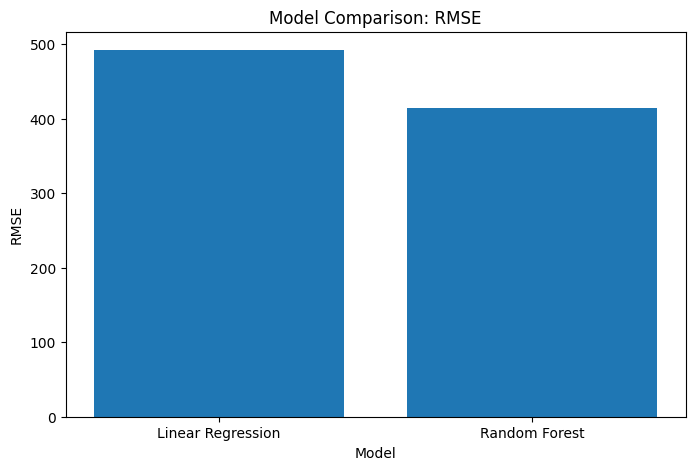

In [30]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

models = ['Linear Regression', 'Random Forest']
rmse_scores = [lr_rmse, rf_rmse]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.show()

### 10.3 Combined Comparison Chart

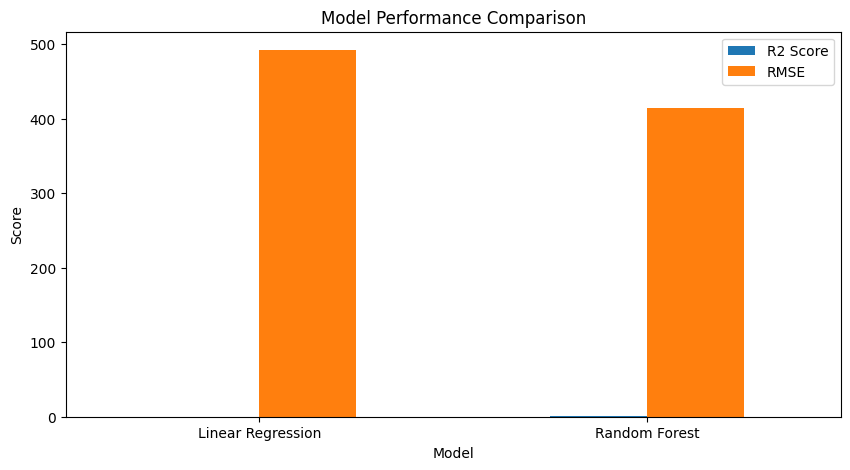

In [31]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [lr_r2, rf_r2],
    'RMSE': [lr_rmse, rf_rmse]
})

comparison.set_index('Model').plot(kind='bar', figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Insight:
Random Forest performs better than Linear Regression because it can capture non-linear relationships in the data, resulting in higher accuracy and lower error.

# 11. Conclusion

This project analyzed EV sales trends in India and identified key growth patterns.

Key findings:

- EV sales are increasing rapidly
- 2-Wheelers dominate EV market
- Maharashtra and Karnataka lead adoption

The Machine Learning model successfully predicts EV sales, which can help in planning infrastructure and policy decisions.



# 12. Future Improvements

- Use more advanced models like XGBoost
- Add population and fuel price data
- Deploy model using Streamlit
- Create dashboard using Power BI or Tableau